# Predictive Maintenance using Deep Learning (LSTM)

### Dataset
NASA C-MAPSS Turbofan Engine Degradation Dataset (FD001)

### Objective
Predict the Remaining Useful Life (RUL) of aircraft engines using sensor data and an LSTM neural network.

In [230]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [231]:
columns = (
    ["unit_number", "time_in_cycles",
     "op_setting_1", "op_setting_2", "op_setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

In [232]:
train = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

In [233]:
train.head()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [234]:
train.shape

(20631, 26)

In [235]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     20631 non-null  int64  
 1   time_in_cycles  20631 non-null  int64  
 2   op_setting_1    20631 non-null  float64
 3   op_setting_2    20631 non-null  float64
 4   op_setting_3    20631 non-null  float64
 5   sensor_1        20631 non-null  float64
 6   sensor_2        20631 non-null  float64
 7   sensor_3        20631 non-null  float64
 8   sensor_4        20631 non-null  float64
 9   sensor_5        20631 non-null  float64
 10  sensor_6        20631 non-null  float64
 11  sensor_7        20631 non-null  float64
 12  sensor_8        20631 non-null  float64
 13  sensor_9        20631 non-null  float64
 14  sensor_10       20631 non-null  float64
 15  sensor_11       20631 non-null  float64
 16  sensor_12       20631 non-null  float64
 17  sensor_13       20631 non-null  float64
 1

In [236]:
train.describe

<bound method NDFrame.describe of        unit_number  time_in_cycles  op_setting_1  op_setting_2  op_setting_3  \
0                1               1       -0.0007       -0.0004         100.0   
1                1               2        0.0019       -0.0003         100.0   
2                1               3       -0.0043        0.0003         100.0   
3                1               4        0.0007        0.0000         100.0   
4                1               5       -0.0019       -0.0002         100.0   
...            ...             ...           ...           ...           ...   
20626          100             196       -0.0004       -0.0003         100.0   
20627          100             197       -0.0016       -0.0005         100.0   
20628          100             198        0.0004        0.0000         100.0   
20629          100             199       -0.0011        0.0003         100.0   
20630          100             200       -0.0032       -0.0005         100.0   

     

In [237]:
train["unit_number"].nunique()

100

In [238]:
train.groupby("unit_number")["time_in_cycles"].max()


unit_number
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: time_in_cycles, Length: 100, dtype: int64

In [239]:
train.groupby("unit_number")["time_in_cycles"].max().sort_values(ascending=False)

unit_number
69    362
92    341
96    336
67    313
83    293
     ... 
58    147
70    137
57    137
91    135
39    128
Name: time_in_cycles, Length: 100, dtype: int64

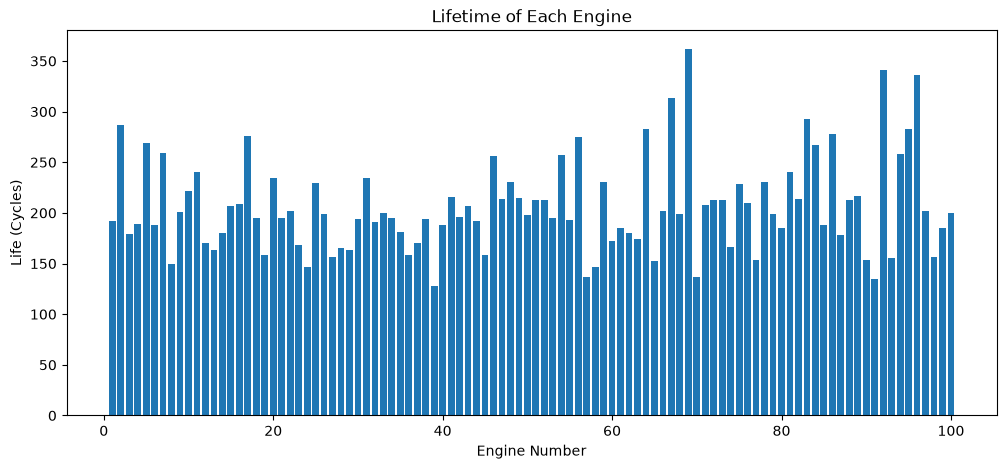

In [240]:
import matplotlib.pyplot as plt

engine_life = train.groupby("unit_number")["time_in_cycles"].max()

plt.figure(figsize=(12,5))
plt.bar(engine_life.index, engine_life.values)
plt.xlabel("Engine Number")
plt.ylabel("Life (Cycles)")
plt.title("Lifetime of Each Engine")
plt.show()

In [241]:
sensor_columns = [f"sensor_{i}" for i in range(1,22)]

train[sensor_columns].std().sort_values()

sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    3.469531e-18
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64

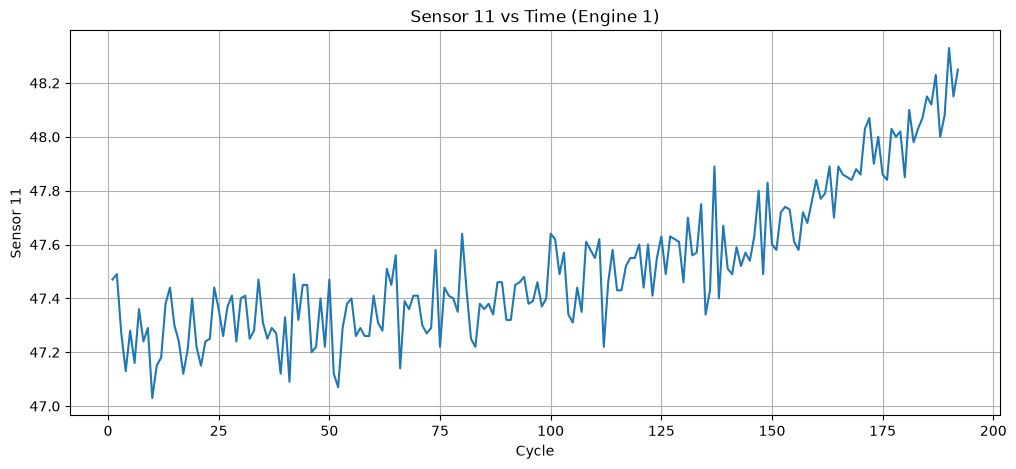

In [242]:
engine1 = train[train["unit_number"] == 1]

plt.figure(figsize=(12,5))
plt.plot(engine1["time_in_cycles"], engine1["sensor_11"])
plt.xlabel("Cycle")
plt.ylabel("Sensor 11")
plt.title("Sensor 11 vs Time (Engine 1)")
plt.grid(True)
plt.show()

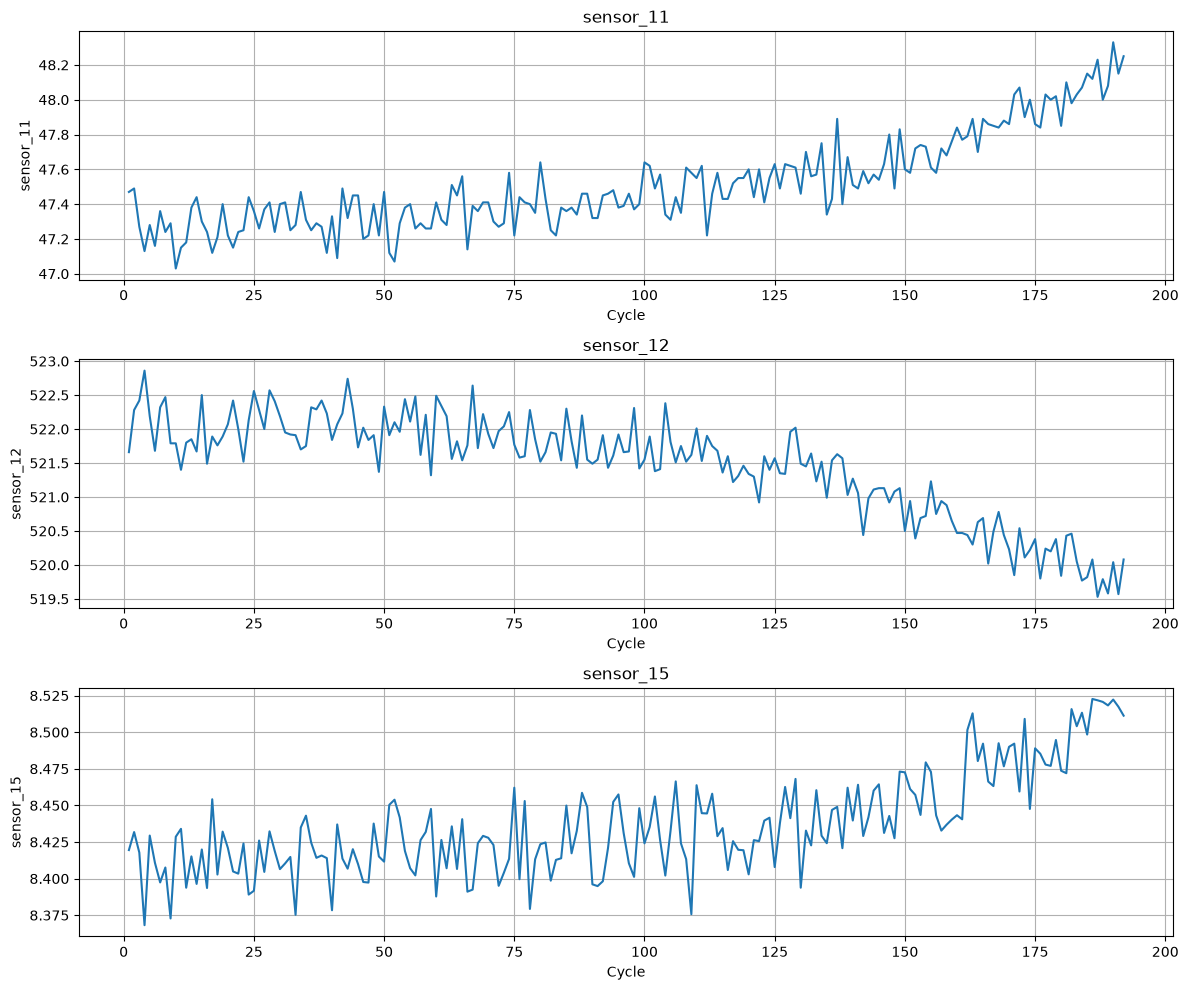

In [243]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

sensors = ["sensor_11", "sensor_12", "sensor_15"]

for i, sensor in enumerate(sensors):
    axes[i].plot(engine1["time_in_cycles"], engine1[sensor])
    axes[i].set_title(sensor)
    axes[i].set_xlabel("Cycle")
    axes[i].set_ylabel(sensor)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [244]:
max_cycle = train.groupby("unit_number")["time_in_cycles"].max()
print(max_cycle.head())

unit_number
1    192
2    287
3    179
4    189
5    269
Name: time_in_cycles, dtype: int64


In [245]:
train = train.merge(
    max_cycle.rename("max_cycle"),
    on="unit_number"
)

In [246]:
train["RUL"] = train["max_cycle"] - train["time_in_cycles"]

In [247]:
train[["unit_number","time_in_cycles","max_cycle","RUL"]].head(10)

,unit_number,time_in_cycles,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187
5,1,6,192,186
6,1,7,192,185
7,1,8,192,184
8,1,9,192,183
9,1,10,192,182


In [248]:
sequence_lenght=30

In [249]:
feature_columns = [
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
] + [f"sensor_{i}" for i in range(1,22)]

In [250]:
def create_sequences(data, seq_length, feature_cols):
    X = []
    y = []

    for engine_id in data["unit_number"].unique():

        engine_data = data[data["unit_number"] == engine_id]

        features = engine_data[feature_cols].values
        labels = engine_data["RUL"].values

        for i in range(len(engine_data) - seq_length + 1):
            X.append(features[i:i + seq_length])
            y.append(labels[i + seq_length - 1])

    return np.array(X), np.array(y)

In [251]:
X, y = create_sequences(train,sequence_lenght , feature_columns)

In [252]:
print(X.shape)
print(y.shape)

(17731, 30, 24)
(17731,)


In [253]:
print("y min:", y.min())
print("y max:", y.max())
print(y[:10])

y min: 0
y max: 332
[162 161 160 159 158 157 156 155 154 153]


In [254]:
print("First sequence shape:", X[0].shape)
print("First target (RUL):", y[0])

First sequence shape: (30, 24)
First target (RUL): 162


In [255]:
print(X[0])

[[-7.00000e-04 -4.00000e-04  1.00000e+02  5.18670e+02  6.41820e+02
   1.58970e+03  1.40060e+03  1.46200e+01  2.16100e+01  5.54360e+02
   2.38806e+03  9.04619e+03  1.30000e+00  4.74700e+01  5.21660e+02
   2.38802e+03  8.13862e+03  8.41950e+00  3.00000e-02  3.92000e+02
   2.38800e+03  1.00000e+02  3.90600e+01  2.34190e+01]
 [ 1.90000e-03 -3.00000e-04  1.00000e+02  5.18670e+02  6.42150e+02
   1.59182e+03  1.40314e+03  1.46200e+01  2.16100e+01  5.53750e+02
   2.38804e+03  9.04407e+03  1.30000e+00  4.74900e+01  5.22280e+02
   2.38807e+03  8.13149e+03  8.43180e+00  3.00000e-02  3.92000e+02
   2.38800e+03  1.00000e+02  3.90000e+01  2.34236e+01]
 [-4.30000e-03  3.00000e-04  1.00000e+02  5.18670e+02  6.42350e+02
   1.58799e+03  1.40420e+03  1.46200e+01  2.16100e+01  5.54260e+02
   2.38808e+03  9.05294e+03  1.30000e+00  4.72700e+01  5.22420e+02
   2.38803e+03  8.13323e+03  8.41780e+00  3.00000e-02  3.90000e+02
   2.38800e+03  1.00000e+02  3.89500e+01  2.33442e+01]
 [ 7.00000e-04  0.00000e+00  1.

In [256]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [257]:
model = Sequential([
    LSTM(64, input_shape=(30, 24)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

c:\machinery presiction\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [258]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


In [259]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 64)             │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,897 (97.25 KB)

 Trainable params: 24,897 (97.25 KB)

 Non-trainable params: 0 (0.00 B)

In [260]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [261]:
print(X_train.shape)
print(X_val.shape)

(14184, 30, 24)
(3547, 30, 24)


In [262]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64
)

Epoch 1/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 9932.8311 - mae: 79.7238 - val_loss: 5987.8057 - val_mae: 59.2058
Epoch 2/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4452.6787 - mae: 52.6588 - val_loss: 3833.7144 - val_mae: 50.2918
Epoch 3/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3920.3169 - mae: 50.8823 - val_loss: 3826.1475 - val_mae: 50.4190
Epoch 4/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3937.7622 - mae: 51.0102 - val_loss: 3825.6465 - val_mae: 50.4610
Epoch 5/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3922.7090 - mae: 50.8731 - val_loss: 3825.7837 - val_mae: 50.4425
Epoch 6/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3895.1360 - mae: 50.7621 - val_loss: 3825.6990 - val_mae: 50.5011
Epoch 7/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3912.3398 - mae: 50.9530 - val_loss: 3825.9902 - val_mae: 50.4271
Epoch 8/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3925.5315 - mae: 50.9462 - val_loss: 3826.0371 - val_m

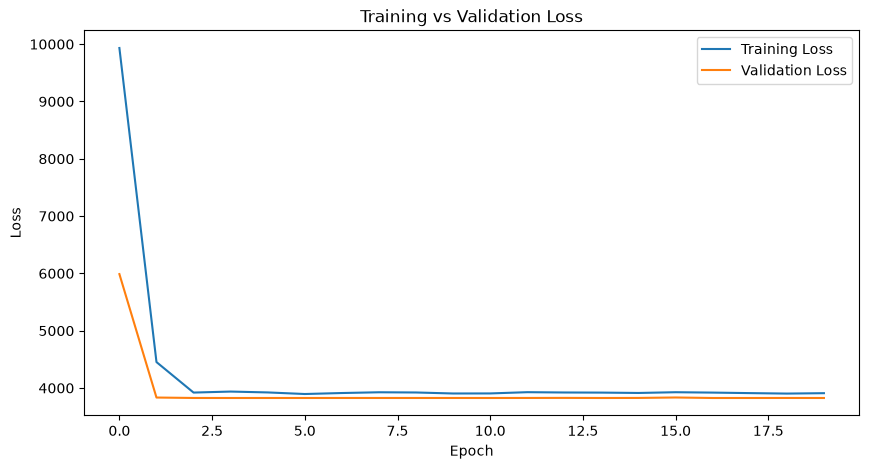

In [263]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [264]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [265]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop]
)


Epoch 1/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 3912.5164 - mae: 50.9602 - val_loss: 3827.2007 - val_mae: 50.3825
Epoch 2/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 3918.8525 - mae: 50.9434 - val_loss: 3838.4062 - val_mae: 50.8529
Epoch 3/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 3916.9104 - mae: 51.0140 - val_loss: 3825.6455 - val_mae: 50.4921
Epoch 4/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 3926.5676 - mae: 50.9849 - val_loss: 3825.6892 - val_mae: 50.4997
Epoch 5/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3925.7068 - mae: 51.1128 - val_loss: 3827.7336 - val_mae: 50.3690
Epoch 6/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 3906.9878 - mae: 50.8528 - val_loss: 3825.6626 - val_mae: 50.4954
Epoch 7/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3911.6582 - mae: 50.8792 - val_loss: 3828.1990 - val_mae: 50.6256
Epoch 8/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 3911.3381 - mae: 50.9617 - val_loss: 3827.

In [266]:
test = pd.read_csv(
    "test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

test.head()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [267]:
print(test.shape)
print(test["unit_number"].nunique())

(13096, 26)
100


In [268]:
rul = pd.read_csv(
    "RUL_FD001.txt",
    header=None,
    names=["RUL"]
)

rul.head()

,RUL
0,112
1,98
2,69
3,82
4,91


In [269]:
print(rul.shape)

(100, 1)


In [270]:
sequence_length = 30

X_test = []

for unit in test["unit_number"].unique():
    engine = test[test["unit_number"] == unit]

    sequence = engine[sensor_columns + ["time_in_cycles", "op_setting_1", "op_setting_2"]].values

    X_test.append(sequence[-sequence_length:])

X_test = np.array(X_test)

print(X_test.shape)

(100, 30, 24)


In [271]:
predictions = model.predict(X_test)

print(predictions.shape)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
(100, 1)


In [272]:
y_test = pd.read_csv(
    "RUL_FD001.txt",
    header=None,
    names=["RUL"]
)

print(y_test.shape)
y_test.head()

(100, 1)


,RUL
0,112
1,98
2,69
3,82
4,91


In [273]:
y_true = y_test["RUL"].values
y_pred = predictions.flatten()

In [274]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = rul["RUL"].values
predicted = predictions.flatten()

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 64.81622314453125
RMSE: 76.69360585920772


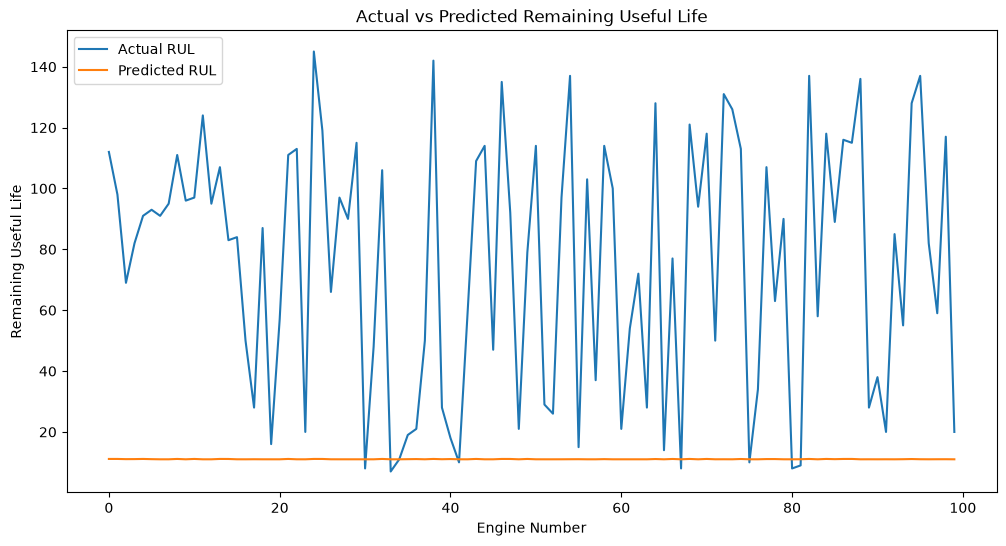

In [275]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(actual, label="Actual RUL")
plt.plot(predicted, label="Predicted RUL")

plt.xlabel("Engine Number")
plt.ylabel("Remaining Useful Life")

plt.title("Actual vs Predicted Remaining Useful Life")

plt.legend()

plt.show()

In [276]:
print("MAE :", mae)
print("RMSE:", rmse)

MAE : 64.81622314453125
RMSE: 76.69360585920772


In [277]:
from sklearn.preprocessing import StandardScaler

In [278]:
features = sensor_columns + [
    "time_in_cycles",
    "op_setting_1",
    "op_setting_2"
]

In [279]:
scaler = StandardScaler()

train[features] = scaler.fit_transform(train[features])

In [280]:
test[features] = scaler.transform(test[features])

In [281]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(30,24)),
    Dropout(0.3),

    LSTM(64),

    Dense(64, activation="relu"),
    Dense(32, activation="relu"),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

c:\machinery presiction\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 30, 128)        │        78,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,017 (523.50 KB)

 Trainable params: 134,017 (523.50 KB)

 Non-trainable params: 0 (0.00 B)

In [282]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - loss: 5615.1929 - mae: 58.8977 - val_loss: 3827.8491 - val_mae: 50.6133
Epoch 2/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 3839.4343 - mae: 50.5457 - val_loss: 3834.2837 - val_mae: 50.7763
Epoch 3/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 3841.8025 - mae: 50.5599 - val_loss: 3827.4504 - val_mae: 50.5995
Epoch 4/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 3839.8779 - mae: 50.5430 - val_loss: 3848.6626 - val_mae: 51.0147
Epoch 5/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 3848.3547 - mae: 50.6202 - val_loss: 3827.2458 - val_mae: 50.3813
Epoch 6/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 3841.1741 - mae: 50.5625 - val_loss: 3825.6228 - val_mae: 50.4674
Epoch 7/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 3842.9358 - mae: 50.5592 - val_loss: 3830.8823 - val_mae: 50.3200
Epoch 8/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 3841.8989 - mae: 50.5580 - val_loss: 3826

In [283]:
pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE :", mae)
print("RMSE:", rmse)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step
MAE : 75.52253723144531
RMSE: 86.20049247158481


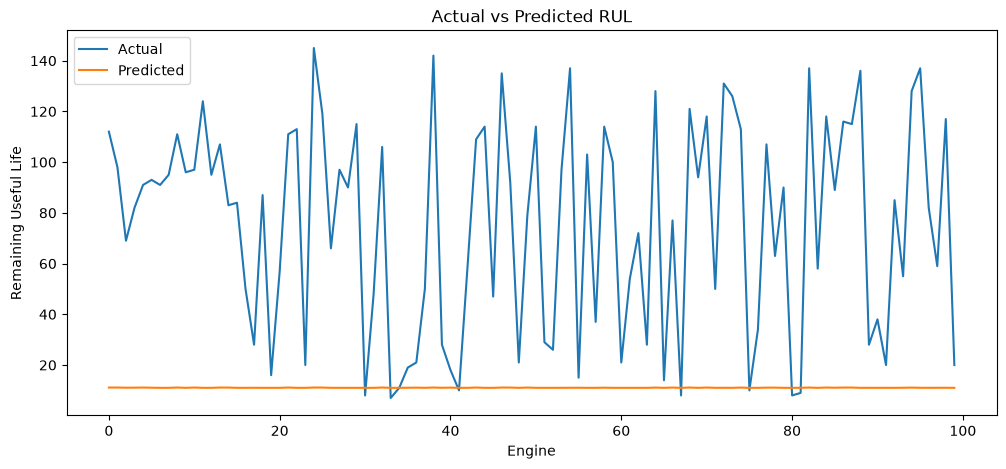

In [284]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_true, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted RUL")
plt.xlabel("Engine")
plt.ylabel("Remaining Useful Life")
plt.show()

In [285]:
print("y_train min:", y_train.min())
print("y_train max:", y_train.max())
print("y_test min:", y_test.min())
print("y_test max:", y_test.max())

y_train min: 0
y_train max: 332
y_test min: RUL    7
dtype: int64
y_test max: RUL    145
dtype: int64


In [286]:
print(y_pred[:10])

[11.124458 11.124428 11.059151 11.074461 11.122823 11.053959 11.007114
 11.007299 11.124358 11.006778]


In [287]:
drop_columns = [
    "sensor_1",
    "sensor_5",
    "sensor_6",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19"
]


In [288]:
train = train.drop(columns=drop_columns)
test = test.drop(columns=drop_columns)

In [289]:
sensor_columns = [col for col in train.columns if col.startswith("sensor")]


In [290]:
print(len(sensor_columns))
print(sensor_columns)

14
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [291]:
rul = train.groupby("unit_number")["time_in_cycles"].transform("max") - train["time_in_cycles"]
train["RUL"] = rul

In [292]:
train["RUL"] = train["RUL"].clip(upper=125)

In [293]:
print(train["RUL"].describe())

count    20631.000000
mean         1.565170
std          1.000024
min          0.000000
25%          0.740425
50%          1.495369
75%          2.250313
max          5.241051
Name: RUL, dtype: float64


In [294]:
feature_columns = [
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
] + sensor_columns

In [295]:
X, y = create_sequences(train, sequence_length, feature_columns)

In [296]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [297]:
print(X_train.shape)
print(X_val.shape)
print(X_train.shape[2])

(14184, 30, 17)
(3547, 30, 17)
17


In [298]:
X_test = []

for unit in test["unit_number"].unique():
    engine = test[test["unit_number"] == unit]

    sequence = engine[feature_columns].values

    X_test.append(sequence[-sequence_length:])

X_test = np.array(X_test)

print(X_test.shape)

(100, 30, 17)


In [299]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("Version 2 Results")
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))

Version 2 Results
MAE : 64.82
RMSE: 76.69


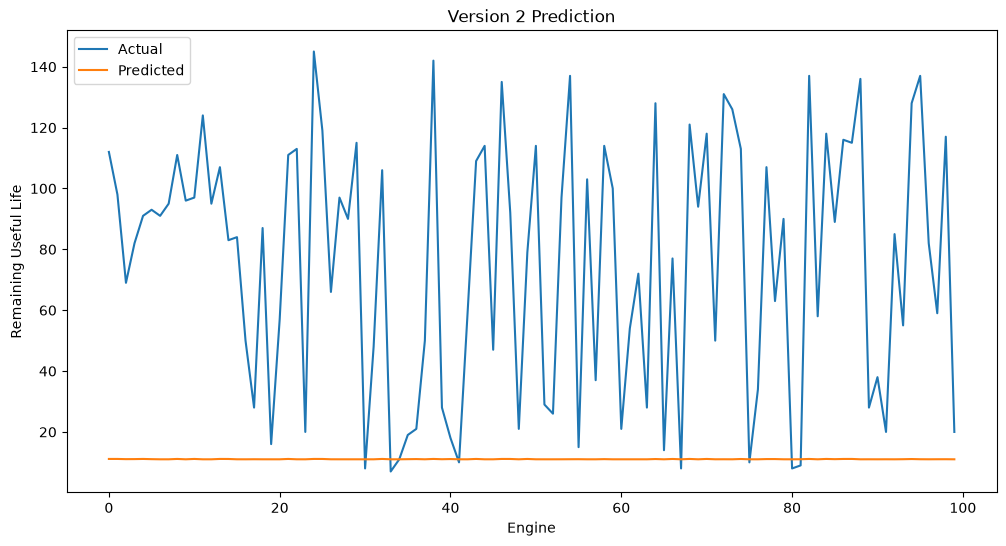

In [300]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_true, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.xlabel("Engine")
plt.ylabel("Remaining Useful Life")

plt.title("Version 2 Prediction")

plt.legend()
plt.show()

In [301]:
model.save("lstm_rul_model.keras")

In [302]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [303]:
from tensorflow.keras.models import load_model

loaded_model = load_model("lstm_rul_model.keras")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [304]:
loaded_scaler = joblib.load("scaler.pkl")

print("Scaler Loaded Successfully!")

Scaler Loaded Successfully!


In [305]:
prediction = loaded_model.predict(X_test)

print(prediction[:5])

ValueError: Exception encountered when calling LSTMCell.call().

[1mDimensions must be equal, but are 17 and 24 for '{{node sequential_8_1/lstm_11_1/lstm_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](sequential_8_1/lstm_11_1/strided_slice_1, sequential_8_1/lstm_11_1/lstm_cell_1/Cast/ReadVariableOp)' with input shapes: [32,17], [24,512].[0m

Arguments received by LSTMCell.call():
  • inputs=tf.Tensor(shape=(32, 17), dtype=float32)
  • states=('tf.Tensor(shape=(32, 128), dtype=float32)', 'tf.Tensor(shape=(32, 128), dtype=float32)')
  • training=False

In [ ]:
import tensorflow as tf
print(tf.__version__)

In [ ]:
model.save("lstm_rul_model.h5")

In [ ]:
model.save_weights("lstm_weights.weights.h5")

In [ ]:
model.summary()

In [ ]:
model.save_weights("new_weights.weights.h5")

In [ ]:
print(features)

In [ ]:
import joblib

scaler = joblib.load("scaler.pkl")

print(type(scaler))
print(scaler.n_features_in_)

In [ ]:
import os
print(os.path.abspath("scaler.pkl"))

In [ ]:
model.input_shape

In [ ]:
print(X_train.shape)

(14184, 30, 24)


In [ ]:
print(model.input_shape)

(None, 30, 24)


In [ ]:
model.save_weights("version2.weights.h5")

In [ ]:
import os
print(os.listdir())

['.venv', '.vscode', 'app.py', 'Damage Propagation Modeling.pdf', 'lstm_rul_model.h5', 'lstm_rul_model.keras', 'lstm_weights.weights.h5', 'new_weights.weights.h5', 'readme.md', 'readme.txt', 'requirements.txt', 'RUL_FD001.txt', 'RUL_FD002.txt', 'RUL_FD003.txt', 'RUL_FD004.txt', 'scaler.pkl', 'test_FD001.txt', 'test_FD002.txt', 'test_FD003.txt', 'test_FD004.txt', 'train_FD001.txt', 'train_FD002.txt', 'train_FD003.txt', 'train_FD004.txt', 'Untitled-1.ipynb', 'Untitled-1.zip', 'version2.weights.h5', 'x.txt']
